# Parallel Parameter Sweeps and Wide Lineage Trees (Predator-Prey)

> **Prerequisites**
>
> This notebook assumes you have read the [Usage Guide](../docs/usage-guide.md), but it also introduces the main ideas as they appear in a complete workflow.

This notebook has two related threads. You can read it for either one.

- **Parallel sweeps**: how to fan out many independent runs with `scenario.map_runs(...)` while keeping the notebook code small.
- **Wide lineage trees**: how Consist records one parent scenario with many child runs, so every output can be traced back to the exact parameters and code that produced it.

A wide lineage tree is what you get when one study, experiment, or scenario has many sibling runs underneath it. Parameter sweeps and Monte Carlo studies naturally have this shape: one parent describes the overall study, and each child run records one point in the sweep.

## Notebook Goals

By the end, you should understand how to:

- Build a plain DataFrame registry that says what should run.
- Use `scenario.map_runs(...)` to execute registry rows in parallel.
- Keep cache identity (`config`) separate from queryable metadata (`facet`).
- Treat the resulting parent scenario and child runs as a lineage tree.
- Query results across all child runs without manually tracking filenames.
- Inspect the DuckDB provenance database to see what Consist stored.

## Reading Paths

If you mostly care about parallel execution, focus on sections 2 through 4. Those sections show the registry, `map_runs(...)`, and cache reuse.

If you mostly care about lineage and provenance, focus on sections 3, 6, and 8. Those sections show how child runs are linked to the parent scenario, how facets make the tree queryable, and what lands in the database.

## Outline

1. Preview one simulation so the model output is concrete.
2. Build a sweep registry: one row per intended child run.
3. Run the sweep with `scenario.map_runs(...)`.
4. Rerun the same sweep to demonstrate cache hits.
5. Export a typed schema for the simulation output artifact.
6. Query across all child runs with Ibis-first expressions over the grouped view.
7. Interpret the aggregate results.
8. Inspect the database tables behind the lineage tree.


## 0) Setup

This notebook writes outputs and DuckDB databases under `examples/runs/`.

We create one `Tracker`, which is the object that owns the run directory, database connection, artifact registry, and cache identity settings. In this example it also acts as the bridge between the notebook and the lineage tree we build later.

The important setup pieces are:

- **Run directory**: where child run outputs and JSON snapshots are written.
- **DuckDB database**: where runs, artifacts, facets, and queryable artifact data are indexed.
- **Example source modules**: importable Python files under `examples/src/` that worker processes can load.

The worker function used by `map_runs(...)` is defined in `examples/src/pipeline_steps.py` and passed as the string `"pipeline_steps:run_one_simulation_sweep"`. The string form is intentional: the current process backend starts fresh Python workers, so the callable must be importable rather than notebook-local.

For a clean demonstration, the setup cell removes the previous demo run directory before creating the tracker. In a real project you would usually keep a stable `run_dir` and `db_path` so Consist can reuse prior results.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import consist


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (missing pyproject.toml)")


REPO_ROOT = _find_repo_root(Path.cwd())
EXAMPLES_DIR = REPO_ROOT / "examples"
EXAMPLES_SRC = EXAMPLES_DIR / "src"

for path in (REPO_ROOT, EXAMPLES_SRC):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

In [2]:
import itertools
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from consist import Tracker, run_query

from pipeline_steps import run_one_simulation
from synth_simulation import PredatorPreyConfig

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = 'svg'

RUN_DIR = EXAMPLES_DIR / "runs" / "predator_prey_demo"
SESSION_ID = os.getenv("CONSIST_SESSION_ID", "demo")
DB_PATH = RUN_DIR / f"predator_prey_demo_{SESSION_ID}.duckdb"

# Clean run artifacts and DB so first sweep starts from true cache misses.
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)
if DB_PATH.exists():
    DB_PATH.unlink()

tracker = Tracker(run_dir=RUN_DIR, db_path=DB_PATH)

## 1) Single Simulation Preview

Before running many cases, we run one predator-prey simulation directly. This cell is not the Consist workflow yet; it is just a quick model sanity check.

The model produces a time series with prey and predator populations at each timestep. The sweep later changes rates and random seeds to ask which parameter regions tend toward coexistence, oscillation, or extinction.

This preview gives the rest of the notebook a concrete artifact shape: every child run in the sweep will produce one `sim_series` table with the same columns.


,t,prey,predator,prey_births,prey_eaten,predator_births,predator_deaths
0,0,80,25,58,26,2,6
1,1,112,21,86,23,8,2
2,2,175,27,125,51,11,5


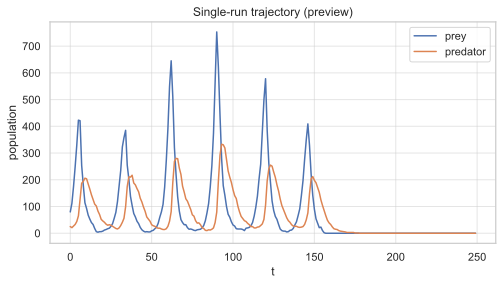

In [3]:
base_config = PredatorPreyConfig(
    steps=250,
    sample_every=1,
    prey_init=80,
    predator_init=25,
    predator_birth_efficiency=0.20,
)

preview_row = {
    "seed": 7,
    "prey_birth_rate": 0.70,
    "predation_rate": 0.011,
    "predator_birth_efficiency": 0.20,
    "predator_death_rate": 0.18,
}

preview_series = run_one_simulation(
    base_config=base_config,
    registry_row=preview_row,
)
display(preview_series.head(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(preview_series["t"], preview_series["prey"], label="prey")
ax.plot(preview_series["t"], preview_series["predator"], label="predator")
ax.set_title("Single-run trajectory (preview)")
ax.set_xlabel("t")
ax.set_ylabel("population")
ax.legend()
plt.show()

## 2) Define the Sweep

A sweep starts with a **registry**: a table where each row describes one run we want to execute. Here the registry is a DataFrame built from parameter combinations and replicate seeds.

This pattern is deliberately simple. The registry is regular Python data, not a Consist-specific object. Consist enters when we pass the rows to `scenario.map_runs(...)` in the next section.

The registry carries three kinds of information:

- **Parameters** such as prey birth rate, predation rate, and predator death rate.
- **Replicates** so each parameter setting is tested under multiple random seeds.
- **Identifiers** such as `sim_id` and `setting_id` that make the lineage tree easy to query.

`sim_id` is unique for every child run. `setting_id` is shared by replicates of the same parameter combination, which lets us aggregate across seeds later.


In [4]:
prey_birth_rates = [0.60, 0.70, 0.75]
predation_rates = [0.008, 0.011, 0.014]
predator_death_rates = [0.15]
predator_birth_efficiency = 0.20
replicates_per_setting = 10

rng = np.random.default_rng(7)

rows = []
for setting_id, (pbr, pr, pdr) in enumerate(
    itertools.product(prey_birth_rates, predation_rates, predator_death_rates)
):
    seeds = rng.integers(0, 2**31, size=replicates_per_setting)
    for replicate_id, seed in enumerate(seeds):
        rows.append(
            {
                "sim_id": len(rows),
                "setting_id": setting_id,
                "replicate_id": replicate_id,
                "prey_birth_rate": pbr,
                "predation_rate": pr,
                "predator_death_rate": pdr,
                "predator_birth_efficiency": predator_birth_efficiency,
                "seed": int(seed),
            }
        )

registry = pd.DataFrame(rows)
print(
    f"sims={len(registry)}  settings={registry['setting_id'].nunique()}  replicates_per_setting={replicates_per_setting}"
)
registry.head()

sims=90  settings=9  replicates_per_setting=10


,sim_id,setting_id,replicate_id,prey_birth_rate,predation_rate,predator_death_rate,predator_birth_efficiency,seed
0,0,0,0,0.6,0.008,0.15,0.2,2029167941
1,1,0,1,0.6,0.008,0.15,0.2,1342382292
2,2,0,2,0.6,0.008,0.15,0.2,1469265226
3,3,0,3,0.6,0.008,0.15,0.2,1926751966
4,4,0,4,0.6,0.008,0.15,0.2,1241873585


## 3) Run the Sweep with Consist

This is the main workflow cell. It creates one parent `scenario` and then fans out one child run per registry row with `scenario.map_runs(...)`.

Conceptually, the result is a wide lineage tree:

```text
predator_prey_sweep              parent scenario run
|-- sim_0000                     child run for registry row 0
|-- sim_0001                     child run for registry row 1
|-- sim_0002                     child run for registry row 2
`-- ...                          one sibling per sweep member
```

Each child run records its own config, status, artifacts, cache signature, and `parent_run_id`. The parent scenario records the study-level config: the base model settings, parameter grid, and replicate count.

### What `map_runs(...)` Adds

Without `map_runs(...)`, a notebook usually needs a loop, a process pool, worker bootstrap code, exception collection, and manual summary bookkeeping. `map_runs(...)` keeps those mechanics in Consist:

- `rows=` supplies the registry rows.
- `fn=` names the importable worker function executed by each process.
- `name_template=` makes stable human-readable child run names.
- `config_from=` builds the cache-relevant config for each child run.
- `facet_from=` extracts small queryable fields for later filtering and aggregation.
- `expected_outputs=` tells Consist which output artifact keys each child should produce.

### `config` vs `facet`

`config` answers: **would changing this value change the computation?** It contributes to cache identity.

`facet` answers: **do I want to filter, group, or label runs by this value later?** It is indexed for queries.

In this notebook, the facets are a subset of the config. Keeping the distinction explicit matters in larger workflows because some labels are useful for search but should not invalidate caches.

### Output Artifacts

The worker returns a DataFrame. Because `expected_outputs=["sim_series"]`, Consist logs that DataFrame as the `sim_series` artifact for each child run. Later cells query all of those sibling artifacts as one logical collection.


In [5]:
from dataclasses import asdict


def sweep_config():
    return {
        "base": asdict(base_config),
        "sweep": {
            "prey_birth_rates": sorted(registry["prey_birth_rate"].unique().tolist()),
            "predation_rates": sorted(registry["predation_rate"].unique().tolist()),
            "predator_death_rates": sorted(
                registry["predator_death_rate"].unique().tolist()
            ),
            "replicates_per_setting": int(registry["replicate_id"].max() + 1),
        },
    }


def run_sweep_scenario(*, scenario_id, tags):
    with consist.scenario(
        scenario_id,
        tracker=tracker,
        config=sweep_config(),
        tags=tags,
    ) as scenario:
        return scenario.map_runs(
            rows=registry.to_dict(orient="records"),
            fn="pipeline_steps:run_one_simulation_sweep",
            name_template="sim_{sim_id:04d}",
            model="simulate",
            config_from=lambda row: {
                "steps": base_config.steps,
                "dt": base_config.dt,
                "prey_init": base_config.prey_init,
                "predator_init": base_config.predator_init,
                "sample_every": base_config.sample_every,
                **row,
            },
            facet_from=lambda row: {
                "sim_id": int(row["sim_id"]),
                "setting_id": int(row["setting_id"]),
                "replicate_id": int(row["replicate_id"]),
                "prey_birth_rate": float(row["prey_birth_rate"]),
                "predation_rate": float(row["predation_rate"]),
                "predator_death_rate": float(row["predator_death_rate"]),
            },
            expected_outputs=["sim_series"],
            backend="processes",
        )


scenario_id = "predator_prey_sweep"
res = run_sweep_scenario(
    scenario_id=scenario_id,
    tags=["examples", "simulation", "predator_prey"],
)

sample_run_id = res.results[0].run_id
sample_run = tracker.get_run(sample_run_id)
assert sample_run is not None
assert sample_run.parent_run_id is not None
scenario_run_id = sample_run.parent_run_id
sample_series_artifact = tracker.get_artifact("sim_series", run_id=sample_run_id)

assert sample_series_artifact is not None
print(
    f"Completed {len(registry)} simulations across {registry['setting_id'].nunique()} parameter settings"
)

(Background on this error at: https://sqlalche.me/e/20/e3q8)


Completed 90 simulations across 9 parameter settings


## 4) Rerun the Sweep: Cache Check

Now we submit the same registry again under a second parent scenario. The child run IDs differ because this is a new scenario, but the child configs, code identity, and expected outputs match the first sweep.

That is enough for Consist to recognize cache hits. Instead of recomputing every simulation, Consist can reuse matching prior results and report `cache_hit_count / total_count`.

This section is useful even if you only care about parallel execution: it shows that parallel fan-out and cache reuse are part of the same run contract. It is also useful if you only care about lineage: the rerun creates another parent scenario whose children point back to reusable work through their cache signatures.


In [6]:
rerun_scenario_id = f"{scenario_id}_rerun"

res2 = run_sweep_scenario(
    scenario_id=rerun_scenario_id,
    tags=["examples", "simulation", "predator_prey", "cache-check"],
)

print(
    f"Second sweep cache hits (hits/total): {res2.cache_hit_count}/{res2.total_count}"
)

Second sweep cache hits (hits/total): 90/90


## 5) Schema Export: From Artifacts to Typed Queries

Each child run produced a `sim_series` artifact. To query those artifacts as tables, Consist needs to know their schema.

The workflow here is:

1. Pick one representative `sim_series` artifact.
2. Ingest it so DuckDB can inspect the columns and types.
3. Export a SQLModel stub from the observed schema.
4. Use a checked-in schema class for the query examples.

The generated class is a starting point, not a final data model. In real projects, you would usually review it, add documentation or constraints, and keep the checked version in source control.

Typed schemas are helpful for both goals of this notebook. Sweep users get safer aggregate queries across many outputs. Lineage users get a documented contract for what each output artifact contains.


In [7]:
from checked_models import PredatorPreySeriesChecked

tracker.ingest(sample_series_artifact)

stub = tracker.export_schema_sqlmodel(
    artifact_id=sample_series_artifact.id,
    class_name="PredatorPreySeriesGenerated",
    table_name="sim_series",
)

print("Generated SQLModel stub:")
print(stub[: stub.find("class") + 90] + "...")  # Show first part
print()
print(f"Using checked-in model: {PredatorPreySeriesChecked.__name__}")

Generated SQLModel stub:
from __future__ import annotations

from typing import Any, Optional

from sqlalchemy import BigInteger, Column, JSON

from sqlmodel import Field, SQLModel
# Generated by Consist schema export (schema_id=2f62a9e917e7f825345c1697378232a0bea5714f45c1bc3aa6bdc2e320e15c2c).
# NOTE: This class is `__abstract__` by default so it can be imported without
# requiring a primary key...

Using checked-in model: PredatorPreySeriesChecked


## 6) Query Across the Wide Lineage Tree

At this point we have many sibling child runs, each with one `sim_series` artifact and queryable facets. The question is no longer how to run the model; it is how to ask questions across the whole tree.

We want summary metrics by parameter setting, such as extinction rates and final population sizes, without writing a loop over output files.

The query now has two small steps:

1. Create one grouped view over the matching `sim_series` artifacts for this sweep scenario and attach the parameter facets so they are available as typed columns.
2. Use Ibis expressions over that view to roll up per-run metrics and then summarize across settings.

The grouped-view helper resolves the stored schema from the sampled `sim_series` artifact and, because these sweep dimensions were logged through `facet_from`, it falls back to the run facets for the attached columns when needed. Attached facets appear as `facet_<name>` columns, which keeps the query surface explicit without adding a wrapper layer.


In [8]:
with tracker.ibis_grouped_view(
    view_name="v_sweep",
    artifact_id=sample_series_artifact.id,
    model="simulate",
    parent_run_id=scenario_run_id,
    attach_facets=[
        "setting_id",
        "prey_birth_rate",
        "predation_rate",
        "predator_death_rate",
    ],
    mode="hybrid",
) as series:
    per_run = series.group_by(
        "consist_run_id",
        "facet_setting_id",
        "facet_prey_birth_rate",
        "facet_predation_rate",
        "facet_predator_death_rate",
    ).aggregate(
        prey_peak=series.prey.max(),
        predator_peak=series.predator.max(),
        prey_final=series.prey.argmax(series.t),
        predator_final=series.predator.argmax(series.t),
        prey_min=series.prey.min(),
        predator_min=series.predator.min(),
    )

    per_run = per_run.mutate(
        setting_id=per_run.facet_setting_id.cast("int64"),
        prey_birth_rate=per_run.facet_prey_birth_rate,
        predation_rate=per_run.facet_predation_rate,
        predator_death_rate=per_run.facet_predator_death_rate,
    )

    summary = per_run.group_by(
        "setting_id",
        "prey_birth_rate",
        "predation_rate",
        "predator_death_rate",
    ).aggregate(
        sims=per_run.consist_run_id.count(),
        prey_extinct_rate=(per_run.prey_min == 0).mean(),
        predator_extinct_rate=(per_run.predator_min == 0).mean(),
        mean_prey_final=per_run.prey_final.mean(),
        mean_predator_final=per_run.predator_final.mean(),
        mean_prey_peak=per_run.prey_peak.mean(),
        mean_predator_peak=per_run.predator_peak.mean(),
    )

    summary_df = summary.execute()

In [9]:
summary_df

,setting_id,prey_birth_rate,predation_rate,predator_death_rate,sims,prey_extinct_rate,predator_extinct_rate,mean_prey_final,mean_predator_final,mean_prey_peak,mean_predator_peak
0,6,0.75,0.008,0.15,10,0.5,0.4,81.4,38.2,1129.8,521.8
1,3,0.70,0.008,0.15,10,1.0,0.9,0.0,0.7,1043.1,452.1
2,0,0.60,0.008,0.15,10,0.9,1.0,2000.2,0.0,2815.1,380.8
3,2,0.60,0.014,0.15,10,1.0,1.0,0.0,0.0,265.5,133.4
4,5,0.70,0.014,0.15,10,1.0,1.0,0.0,0.0,466.1,221.8
5,8,0.75,0.014,0.15,10,0.7,0.7,89.3,30.3,624.2,290.5
6,4,0.70,0.011,0.15,10,0.9,0.9,1.2,3.2,738.8,331.3
7,1,0.60,0.011,0.15,10,1.0,1.0,0.0,0.0,740.8,297.6
8,7,0.75,0.011,0.15,10,0.9,0.7,69.8,14.6,766.6,367.2


## 7) Interpret the Results

The heatmap summarizes the wide lineage tree into one visual. Each square is backed by several child runs: same parameter setting, different replicate seeds.

The interesting region is usually the boundary between stable coexistence and extinction. That boundary is exactly where a sweep is more informative than a single run, because stochastic variation can change the outcome even when the nominal parameters are fixed.

The provenance payoff is what we did not have to do:

- Parse parameter values out of filenames.
- Maintain a side spreadsheet mapping outputs to configs.
- Load every result manually before deciding how to group it.
- Guess which run produced an artifact.

The plot is derived from the recorded lineage: parent scenario, child run configs, facets, and output artifacts.


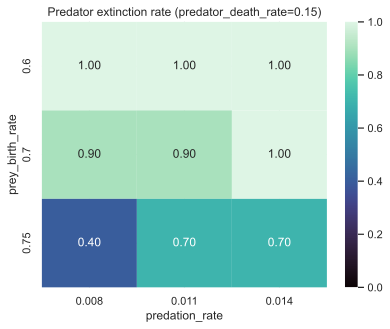

In [10]:
# summary_df was computed in the Ibis cell above.

# Round parameter columns to avoid float precision noise in labels
param_cols = ["prey_birth_rate", "predation_rate", "predator_death_rate"]
summary_df[param_cols] = summary_df[param_cols].round(4)

# Example: visualize extinction risk as a heatmap (fix death rate to one slice)
death_rate = float(sorted(summary_df["predator_death_rate"].unique())[0])
slice_df = summary_df[summary_df["predator_death_rate"] == death_rate]
pivot = slice_df.pivot_table(
    index="prey_birth_rate",
    columns="predation_rate",
    values="predator_extinct_rate",
)

ax = sns.heatmap(pivot.sort_index(), annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1)
ax.set_title(f"Predator extinction rate (predator_death_rate={death_rate})")
ax.set_xlabel("predation_rate")
ax.set_ylabel("prey_birth_rate")
plt.show()

## 8) Inspect the Database

Consist stores the run graph and artifact index in DuckDB. You do not need to inspect these tables for everyday use, but seeing them once helps make the lineage model concrete.

The most important tables are:

| Table | What it represents |
|------|---------------------|
| `run` | One row per parent or child run, including status, cache signature, and `parent_run_id`. |
| `artifact` | Registered files or table-like outputs, including paths, hashes, and schema names. |
| `run_artifact_link` | The edge table linking runs to their input and output artifacts. |
| `config_facet` | Stored facet payloads for runs. |
| `run_config_kv` | Flattened facet key/value rows for filtering and grouping. |

For this notebook, the `run` table should show one parent scenario plus many child simulation runs. The `parent_run_id` column is the database-level representation of the wide lineage tree.

The `global_tables` schema contains ingested artifact data, while grouped views such as `v_sweep` provide the typed query surface used above.

Because Consist stores portable URIs, content hashes, and JSON snapshots under the run directory, the lineage can move with the project more easily than a set of unrelated output files.


In [11]:
from sqlalchemy import func, inspect
from sqlmodel import select

from consist.models import Artifact, ConfigFacet, Run, RunConfigKV

inspector = inspect(tracker.engine)

print("Database schema:")
print(f"  Main tables: {', '.join(inspector.get_table_names())}")
print(
    f"  Global tables: {', '.join(inspector.get_table_names(schema='global_tables'))}"
)
print(f"  Views: {', '.join(inspector.get_view_names())}")
print()


def scalar_count(query):
    value = run_query(query, tracker=tracker)[0]
    return value if isinstance(value, int) else value[0]


table_counts = {
    "run": scalar_count(select(func.count()).select_from(Run)),
    "artifact": scalar_count(select(func.count()).select_from(Artifact)),
    "config_facet": scalar_count(select(func.count()).select_from(ConfigFacet)),
    "run_config_kv": scalar_count(select(func.count()).select_from(RunConfigKV)),
}

print("Row counts:")
for table, count in table_counts.items():
    print(f"  {table}: {count:,}")

print()
print(f"DuckDB file: {DB_PATH.relative_to(REPO_ROOT)}")
print(f"Open UI: duckdb -ui {DB_PATH.relative_to(REPO_ROOT)}")

Database schema:
  Main tables: sim_series, _dlt_loads, _dlt_pipeline_state, _dlt_version, artifact, artifact_content, artifact_facet, artifact_kv, artifact_schema, artifact_schema_field, artifact_schema_observation, artifact_schema_relation, config_facet, run, run_artifact_link, run_config_kv
  Global tables: sim_series, _dlt_loads, _dlt_pipeline_state, _dlt_version
  Views: consist_schema_links, v_sweep

Row counts:
  run: 182
  artifact: 90
  config_facet: 90
  run_config_kv: 1,080

DuckDB file: examples/runs/predator_prey_demo/predator_prey_demo_demo.duckdb
Open UI: duckdb -ui examples/runs/predator_prey_demo/predator_prey_demo_demo.duckdb


## Summary

This notebook introduced two Consist patterns that work together but can be learned independently.

For parallel sweeps:

- Build a registry DataFrame with one row per intended run.
- Keep worker code in an importable module.
- Use `scenario.map_runs(...)` to fan out rows across process workers.
- Use the returned `BatchResult` to inspect successes, failures, cache hits, and persisted child run IDs.

For wide lineage trees:

- Use one parent `scenario` to represent the whole study.
- Let each sweep member become a child run with its own config, facets, and artifacts.
- Store cache-relevant values in `config` and query-relevant values in attached facets.
- Query across sibling runs through grouped views and attached facets.

The key idea is that parallel execution does not have to sacrifice provenance. The same call that fans out the work also gives Consist enough structure to make the result inspectable, cacheable, and queryable later.

## Further Reading

- `examples/03_iterative_workflows.ipynb`: iterative workflows, cache hydration choices, and provenance across feedback loops.
- `examples/04_transportation_demand_modeling.ipynb`: larger scenario analysis patterns with richer domain metadata.
